# Team F1's Linear Regression model

Team members include Patrick, Carter, Jaegeon and Merlin

In [55]:
#importing all the different libraries that we will need for this part. 

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

import numpy as np
from numpy import meshgrid
import matplotlib.pyplot as plt
import seaborn as sns

Here we pull in the data that will to be used for our predictors and qualifiers.  We can pull from two different csv files, but should be careful that they line up. <br>
The list in the X dataframe should contain all the different columns that we want to use, such as "gap_between_mean" or "circuitType_RACE"

In [142]:
xdata = pd.read_csv(r"..\Merlin preview\gaps and circuit type (no DNF).csv")  #or we can use different files for each, but they should be in the right order

ydata = pd.read_csv(r"..\Patrick\Average Local Positions.csv")

xdata2 = pd.read_csv(r"..\paceRankStartPositionDeltas.csv")

xdata = pd.merge(xdata,xdata2, on = "raceId", how='inner')
xdata = pd.merge(xdata,ydata, on = "raceId", how = 'inner')
#,"Bgap_average"
X  = xdata[ ["Bgap_median","absGridDelta","First_ten_gap","circuitType_RACE","circuitType_ROAD","circuitType_STREET","average_local_position","Bgap_mean"]]
X_guess = xdata[["Bgap_median","absGridDelta"]]


X = X.fillna(1000)  #getting rid of any nan variables, and replaces them with 1000, for only a couple NaNs, shouldn't make a big different. 


Y = ydata[ "average_local_position"]  #this is our target, what we are trying to predict, and will use this to test our predictive model. 


X_train,X_test , Y_train, Y_test = train_test_split(X,Y , test_size= 0.2, random_state= 117)


Here we create the pipeline for how our model will be run.  We are using the Linear Regression model, and we are normalizing our predictor values via StandaScalar.

In [133]:
pipe = Pipeline ([
    ('scalar', StandardScaler() ),  #normalizing our features aka the predictors
    ('model' , LinearRegression() )  # this is the model that we are using, which can be anything we want. 
])

pipe2 = Pipeline ([
    ('scalar', StandardScaler() ),  #normalizing our features aka the predictors
    ('poly', PolynomialFeatures(degree = 7, 
                                  interaction_only= False,
                                  include_bias= False) 
                                  ),
                                    ('reg' , LinearRegression())  # this is the model that we are using, which can be anything we want. 
])


Here is where we train the model, making sure not to use any of our testing data.  That would mean there is data leakage. 

In [134]:

pipe.fit(X_train,Y_train)  #here we are fitting our model with the testing data,  DO NOT INCLUDE THE TEST PARTITIONS


Pipeline(steps=[('scalar', StandardScaler()), ('model', LinearRegression())])

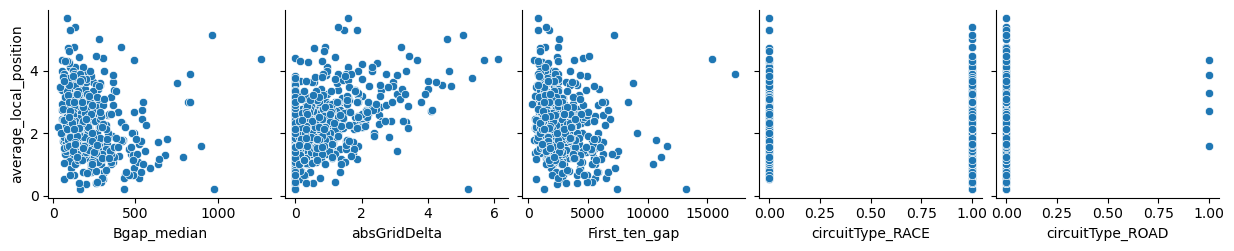

In [143]:
sns.pairplot(
                data=X_train,
                x_vars=["Bgap_median","absGridDelta","First_ten_gap","circuitType_RACE","circuitType_ROAD"],
                y_vars=["average_local_position"],
            )

plt.show()

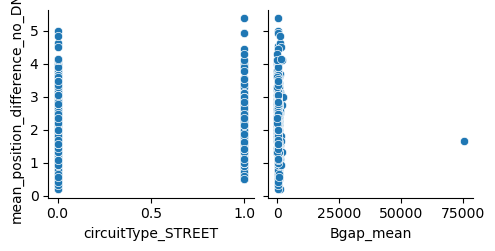

In [126]:
sns.pairplot(
                data=X_train,
                x_vars=["circuitType_STREET","Bgap_mean"],
                y_vars=["mean_position_difference_no_DNF"],
            )

plt.show()

In [127]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

def powerset(s):
    power_set = [[]]
    for x in s:
        power_set += [s0+[x] for s0 in power_set]
    return power_set[1:]

## Make kfold object
kfold = KFold(n_splits=5, 
              shuffle=True, 
              random_state = 5309)

## get all models we're interested in
models = powerset(["Bgap_median","absGridDelta","First_ten_gap","circuitType_RACE","circuitType_ROAD","circuitType_STREET","Bgap_mean"])

## This is the baseline model
models.append("baseline")

## make empty mse holder
cv_mses = np.zeros((5, len(models)))

## loop through all splits
i = 0
for train_index, test_index in kfold.split(X_train):
    ## get train and holdout sets
    car_train_train = X_train.iloc[train_index]
    car_holdout = X_train.iloc[test_index]


    ## loop through all models
    j = 0
    for model in models:
        if model == "baseline":
            car_train_train_mean = car_train_train.mean_position_difference_no_DNF.mean()
            predict = car_train_train_mean * np.ones(len(car_holdout))
            cv_mses[i,j] = r2_score(car_holdout.mean_position_difference_no_DNF, predict)
        else:
            ## make clone
            reg = LinearRegression(copy_X = True)
        
        
            ## fit clone
            reg.fit(car_train_train[model], car_train_train.mean_position_difference_no_DNF)
            predict = reg.predict(car_holdout[model])

            ## record mse
            cv_mses[i,j] = r2_score(car_holdout.mean_position_difference_no_DNF, predict)
        j=j+1
    i=i+1  

In [128]:
## which model had lowest mean mse?
print("The model with highest r2 score included the features", 
      models[np.argmax(np.mean(cv_mses, axis=0))],
      "and had an avg r2 score of",
      np.mean(cv_mses, axis=0)[np.argmax(np.mean(cv_mses, axis=0))])

The model with highest r2 score included the features ['Bgap_median', 'absGridDelta'] and had an avg r2 score of 0.1960965250969249


In [129]:
# Baseline model mean mse
np.mean(cv_mses, axis=0)[-1]

-0.008185187118716363

Now we can use our trained model to make predictions from the testing predictors, and compare them to the actual predictors from the testing set. 

In [135]:

Y_pred = pipe.predict(X_test) 

mse = mean_squared_error(Y_pred, Y_test)
r2 = r2_score(Y_pred,Y_test)


print(f"Mean squared error: {mse}")
print(f"R^2 value : {r2}")

Mean squared error: 0.5861057666483321
R^2 value : -1.8740505019279872


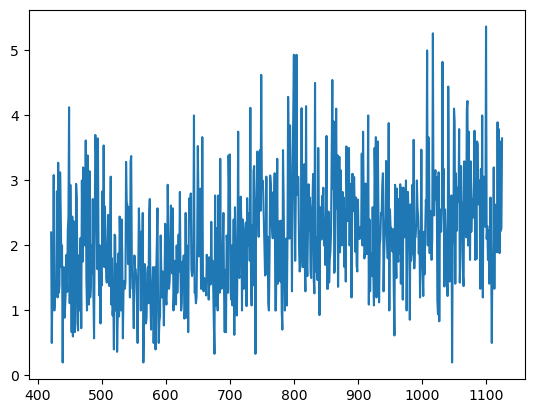

In [138]:
import matplotlib.pyplot as plt

plt.plot(ydata["raceId"],ydata['mean_position_difference_no_DNF'])

#plt.plot(Y_pred)

In [117]:
print(len(Y_pred))
print(Y_test.to_list())

141
[0.0277777777777777, 0.1911764705882352, 0.0808823529411764, 0.0, 0.1428571428571428, 0.1, 0.0666666666666666, 0.0384615384615384, 0.0666666666666666, 0.0, 0.0, 0.1, 0.0222222222222222, 0.0, 0.0384615384615384, 0.0, 0.1666666666666666, 0.0357142857142857, 0.0833333333333333, 0.0, 0.0, 0.1111111111111111, 0.0833333333333333, 0.0, 0.0476190476190476, 0.0363636363636363, 0.0666666666666666, 0.0476190476190476, 0.0659340659340659, 0.0219780219780219, 0.1666666666666666, 0.0879120879120879, 0.0285714285714285, 0.0392156862745098, 0.1071428571428571, 0.0, 0.0, 0.0, 0.1282051282051282, 0.0, 0.0357142857142857, 0.0363636363636363, 0.0, 0.0454545454545454, 0.0, 0.0, 0.0555555555555555, 0.0, 0.0439560439560439, 0.0641025641025641, 0.1071428571428571, 0.0666666666666666, 0.0989010989010989, 0.2, 0.1333333333333333, 0.0, 0.1083333333333333, 0.8333333333333334, 0.1666666666666666, 0.0357142857142857, 0.1, 0.0, 0.1071428571428571, 0.2, 0.0444444444444444, 0.0, 0.0, 0.0, 0.0857142857142857, 0.0, 

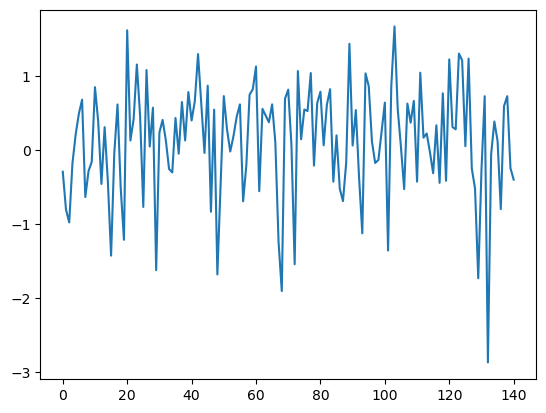

In [139]:
plt.plot((Y_pred- Y_test.to_list()))
